# 安装配置 R 语言环境

```
## 进入 R 编程环境
conda activate LabelTransfer

## 安装所需库
conda create -n LabelTransfer -c conda-forge \
r-base=4.3 \
hdf5 \
r-hdf5r \
r-seurat \
r-seuratobject \
r-arrow \
r-tidyverse \
r-ggplot2 \
r-ggpmisc \
r-cowplot \
r-gridextra \
r-viridis \
r-hrbrthemes \
r-jsonlite \
r-remotes
```

# 安装BPcells

```
## 下载 BPcells 包
cd ~
git clone https://github.com/bnprks/BPCells.git

## 进入 R 环境
R

## 使用本地编译安装
remotes::install_local("~/BPCells/r")
```

# 在 Ipynb 文件中使用 R 环境

```
## 安装所需库
conda install -c conda-forge \
r-irkernel \
jupyter \
notebook \
ipykernel

## 进入 R 注册 kernel
IRkernel::installspec(name = "LabelTransfer", displayname = "R_LabelTransfer")
```

# 在终端中执行，进入你的工作目录

```
cd ./data/
wget https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
unzip Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
```

```
curl -O https://cf.10xgenomics.com/samples/cell-exp/8.0.1/17k_Ovarian_Cancer_scFFPE/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5
```

```
curl -O https://cf.10xgenomics.com/supp/cell-exp/FLEX_Ovarian_Barcode_Cluster_Annotation.csv
```

In [ ]:
# 检查 R 的详细配置
cat("=== R 配置信息 ===\n")
print(R.Version()$version.string)

cat("\n=== 编译器检查 ===\n")
print(system("gcc --version", intern = TRUE))
print(system("g++ --version", intern = TRUE))

cat("\n=== Make 工具检查 ===\n")
print(system("make --version", intern = TRUE))

cat("\n=== 环境变量 PATH ===\n")
print(Sys.getenv("PATH"))

cat("\n=== R 编译标志 ===\n")
print(Sys.getenv("R_CFLAGS"))

=== R 配置信息 ===
[1] "R version 4.3.3 (2024-02-29)"

=== 编译器检查 ===
[1] "gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0"                                
[2] "Copyright (C) 2023 Free Software Foundation, Inc."                          
[3] "This is free software; see the source for copying conditions.  There is NO" 
[4] "warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE."
[5] ""                                                                           
[1] "g++ (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0"                                
[2] "Copyright (C) 2023 Free Software Foundation, Inc."                          
[3] "This is free software; see the source for copying conditions.  There is NO" 
[4] "warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE."
[5] ""                                                                           

=== Make 工具检查 ===
[1] "GNU Make 4.4.1"                                                                
[2] "Built 


=== 环境变量 PATH ===
[1] "/home/ailab/miniconda3/envs/LabelTransfer/bin:/home/ailab/miniconda3/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin"

=== R 编译标志 ===
[1] ""


In [ ]:
# ============================================
# Cell 1: 环境初始化（每次重启内核后运行此单元格即可）
# ============================================

# 设置工作目录
setwd("/home/ailab/caohao/AdaDiss/")

# 加载所有必需的包
suppressPackageStartupMessages({
    library(Seurat)
    library(BPCells)
    library(SeuratObject)
    library(SeuratDisk)
    library(tidyverse)
    library(jsonlite)
    library(ggplot2)
    library(ggpmisc)
    library(scales)
    library(cowplot)
    library(gridExtra)
    library(viridis)
    library(hrbrthemes)
})

# 设置Seurat内存限制
options(future.globals.maxSize = 1e9)

# 定义缓存目录和文件
CACHE_DIR <- "./data/cache/"
FLEX_CACHE <- "./data/cache/flex_data_processed.rds"
XENIUM_CACHE <- "./data/cache/xenium_data_processed.rds"
FLEX_COUNTS_DIR <- "./data/cache/flex_counts_bpcells/"
XENIUM_COUNTS_DIR <- "./data/cache/xenium_counts_bpcells/"

# 创建缓存目录（如果不存在）
if (!dir.exists(CACHE_DIR)) {
    dir.create(CACHE_DIR, recursive = TRUE)
    cat("📁 创建缓存目录:", CACHE_DIR, "\n")
}

# 定义数据处理函数
process_flex_data <- function() {
    cat("🔄 正在处理 Flex 数据...\n")
    
    # 加载原始数据
    flex_path <- "./data/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5"
    flex_data.obj <- Read10X_h5(flex_path)
    flex_data.obj <- CreateSeuratObject(counts = flex_data.obj)
    cat("  ✓ 原始数据加载完成，细胞数:", ncol(flex_data.obj), "\n")
    
    # BPCells 存储
    if (!dir.exists(FLEX_COUNTS_DIR)) {
        write_matrix_dir(mat = flex_data.obj[["RNA"]]$counts, dir = FLEX_COUNTS_DIR)
    }
    flex_data.obj[['RNA']]$counts <- open_matrix_dir(dir = FLEX_COUNTS_DIR)
    cat("  ✓ BPCells 存储配置完成\n")
    
    # QC
    flex_data.obj[["percent.mt"]] <- PercentageFeatureSet(flex_data.obj, pattern = "^MT-")
    flex_data.obj <- subset(flex_data.obj, 
                            subset = nCount_RNA > 200 & nCount_RNA < 10000 & percent.mt < 10)
    cat("  ✓ QC 过滤完成，剩余细胞数:", ncol(flex_data.obj), "\n")
    
    # 添加注释
    flex_annotation_file <- read.csv("./data/FLEX_Ovarian_Barcode_Cluster_Annotation.csv")
    flex_annotations <- setNames(flex_annotation_file$Cell.Annotation, 
                                 flex_annotation_file$Barcode)
    # 只保留当前数据中存在的细胞
    flex_annotations <- flex_annotations[names(flex_annotations) %in% colnames(flex_data.obj)]
    flex_data.obj <- AddMetaData(flex_data.obj, flex_annotations, col.name = 'cell_type')
    cat("  ✓ 细胞类型注释添加完成\n")
    
    return(flex_data.obj)
}

process_xenium_data <- function() {
    cat("🔄 正在处理 Xenium 数据...\n")
    
    # 加载原始数据
    xenium_path <- "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/"
    xenium.obj <- LoadXenium(xenium_path, fov = "fov", molecule.coordinates = FALSE)
    DefaultAssay(xenium.obj) <- "Xenium"
    cat("  ✓ 原始数据加载完成，细胞数:", ncol(xenium.obj), "\n")
    
    # BPCells 存储
    if (!dir.exists(XENIUM_COUNTS_DIR)) {
        write_matrix_dir(mat = xenium.obj[["Xenium"]]$counts, dir = XENIUM_COUNTS_DIR)
    }
    xenium.obj[['Xenium']]$counts <- open_matrix_dir(dir = XENIUM_COUNTS_DIR)
    cat("  ✓ BPCells 存储配置完成\n")
    
    # 过滤空细胞
    n_before <- ncol(xenium.obj)
    xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 0)
    cat("  ✓ 过滤空细胞: 移除", n_before - ncol(xenium.obj), "个空细胞\n")
    
    # 添加元数据
    xenium.obj@meta.data$nCount_Xenium_log <- log1p(xenium.obj@meta.data$nCount_Xenium)
    xenium.obj@meta.data$nFeature_Xenium_log <- log1p(xenium.obj@meta.data$nFeature_Xenium)
    
    return(xenium.obj)
}

# 定义缓存加载函数
load_or_process <- function(cache_file, process_func, data_name) {
    if (file.exists(cache_file)) {
        cat("📦 从缓存加载", data_name, "数据...\n")
        obj <- readRDS(cache_file)
        cat("✅", data_name, "数据加载完成，细胞数:", ncol(obj), "\n")
        return(obj)
    } else {
        cat("📂 首次运行，正在处理", data_name, "数据...\n")
        obj <- process_func()
        saveRDS(obj, cache_file)
        cat("✅", data_name, "数据处理完成并已缓存\n")
        return(obj)
    }
}

cat("\n" + paste(rep("=", 50), collapse = "") + "\n")
cat("🚀 环境初始化完成\n")
cat("📁 缓存目录:", CACHE_DIR, "\n")
cat("💾 包版本信息:\n")
cat("  - Seurat:", packageVersion("Seurat"), "\n")
cat("  - SeuratDisk:", packageVersion("SeuratDisk"), "\n")
cat("  - BPCells:", packageVersion("BPCells"), "\n")
cat(paste(rep("=", 50), collapse = ""), "\n\n")

In [ ]:
# ============================================
# Cell 2: 加载 Flex 参考数据
# ============================================

flex_data.obj <- load_or_process(FLEX_CACHE, process_flex_data, "Flex")

# 查看数据摘要
cat("\n📊 Flex 数据摘要:\n")
print(flex_data.obj)

cat("\n📊 细胞类型分布（前10种）:\n")
print(head(sort(table(flex_data.obj$cell_type), decreasing = TRUE), 10))

cat("\n📊 细胞类型数量:", length(unique(flex_data.obj$cell_type)), "\n")

In [ ]:
# ============================================
# Cell 3: 加载 Xenium 数据
# ============================================

xenium.obj <- load_or_process(XENIUM_CACHE, process_xenium_data, "Xenium")

# 查看数据摘要
cat("\n📊 Xenium 数据摘要:\n")
print(xenium.obj)

cat("\n📊 Xenium 统计:\n")
cat("  - 细胞数量:", ncol(xenium.obj), "\n")
cat("  - 基因数量:", nrow(xenium.obj), "\n")
cat("  - 中位转录本数:", median(xenium.obj$nCount_Xenium), "\n")
cat("  - 中位基因数:", median(xenium.obj$nFeature_Xenium), "\n")

• Consider calling convert_matrix_type if a compressed integer matrix is intended.
This message is displayed once every 8 hours.


18082 x 17553 IterableMatrix object with class MatrixDir

Row names: SAMD11, NOC2L ... MT-CYB
Col names: AAACAAGCAAAGGTAAACTTTAGG-1, AAACAAGCAAATCACGACTTTAGG-1 ... TTTGTGAGTAAACTGGACTTTAGG-2

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /home/ailab/caohao/AdaDiss/data/flex_counts_bpcells

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


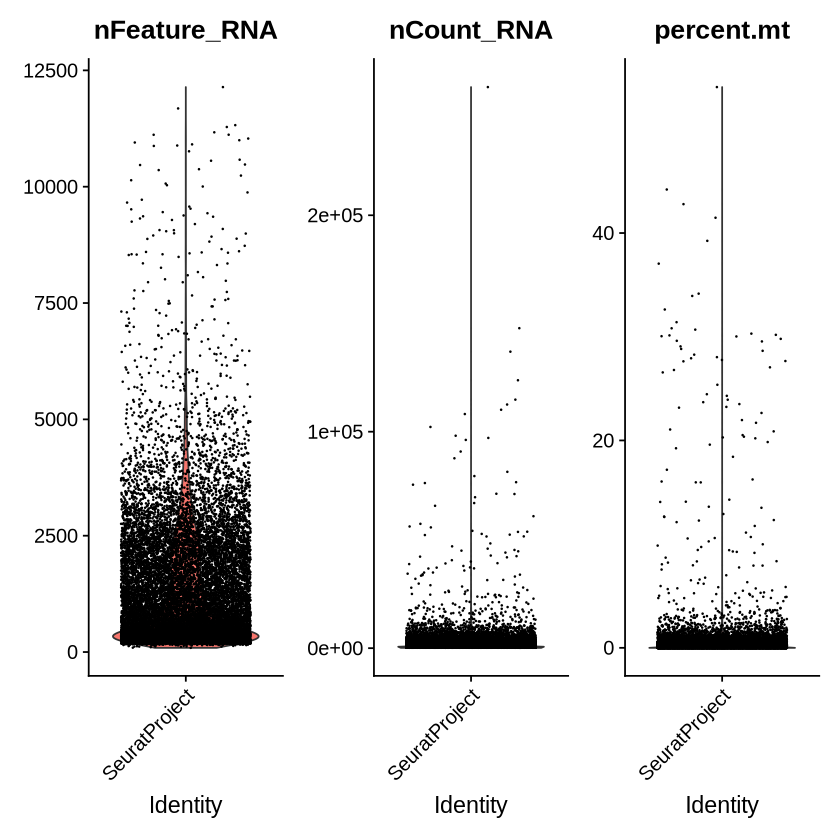

In [ ]:
# # 设置文件路径（根据你的实际目录修改）
# flex_path <- "./data/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5"
# flex_data.obj <- Read10X_h5(flex_path)
# flex_data.obj <- CreateSeuratObject(counts = flex_data.obj)

# # 使用 BPCells 将 counts 矩阵存到磁盘（节省内存）
# counts_dir <- "./data/flex_counts_bpcells/"
# write_matrix_dir(mat = flex_data.obj[["RNA"]]$counts, dir = counts_dir)
# counts.mat <- open_matrix_dir(dir = counts_dir)
# flex_data.obj[['RNA']]$counts <- counts.mat
# rm(counts.mat)

# # 添加线粒体比例并做 QC
# flex_data.obj[["percent.mt"]] <- PercentageFeatureSet(flex_data.obj, pattern = "^MT-")
# VlnPlot(flex_data.obj, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
# flex_data.obj <- subset(flex_data.obj, subset = nCount_RNA > 200 & nCount_RNA < 10000 & percent.mt < 10)

# # 添加细胞类型注释
# flex_annotation_file <- read.csv("./data/FLEX_Ovarian_Barcode_Cluster_Annotation.csv")
# flex_annotations <- flex_annotation_file$Cell.Annotation
# names(flex_annotations) <- flex_annotation_file$Barcode
# flex_data.obj <- AddMetaData(object = flex_data.obj, metadata = flex_annotations, col.name = 'cell_type')

In [ ]:
# xenium_path <- "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/"
# xenium.obj <- LoadXenium(xenium_path, fov = "fov", molecule.coordinates = FALSE)
# DefaultAssay(xenium.obj) <- "Xenium"

# # 使用 BPCells 将 counts 矩阵存到磁盘
# counts_dir <- "./data/xenium_counts_bpcells/"
# write_matrix_dir(mat = xenium.obj[["Xenium"]]$counts, dir = counts_dir)
# counts.mat <- open_matrix_dir(dir = counts_dir)
# xenium.obj[['Xenium']]$counts <- counts.mat
# rm(counts.mat)

# # 简单过滤：去除空细胞（transcript count = 0）
# xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 0)

# # 添加 log 转换后的元数据用于可视化
# xenium.obj@meta.data$nCount_Xenium_log <- log1p(xenium.obj@meta.data$nCount_Xenium)
# xenium.obj@meta.data$nFeature_Xenium_log <- log1p(xenium.obj@meta.data$nFeature_Xenium)

Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


5101 x 407124 IterableMatrix object with class MatrixDir

Row names: A2ML1, AAMP ... ZYX
Col names: aaaaebmm-1, aaaafhpp-1 ... oijbekda-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /home/ailab/caohao/AdaDiss/data/xenium_counts_bpcells

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 41 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”


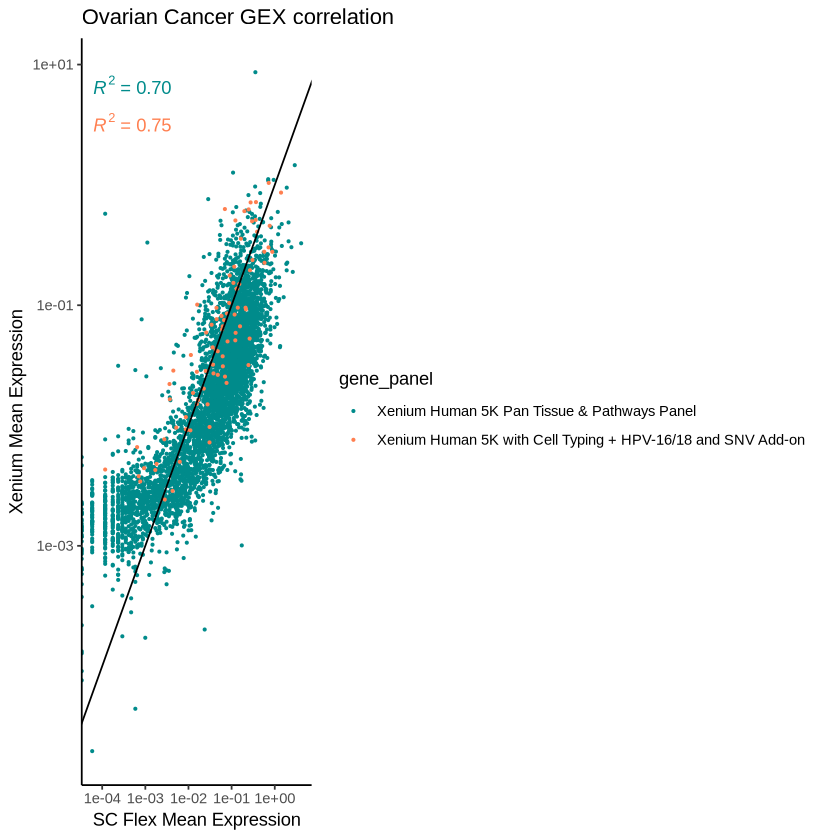

In [10]:
get_gex_means <- function(xenium_obj, flex_obj) {
    xen_means <- data.frame(
        mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
        gene = rownames(xenium_obj[["Xenium"]]$counts)
    ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
    
    flex_means <- data.frame(
        mean_counts = rowMeans(flex_obj[["RNA"]]$counts),
        gene = rownames(flex_obj[["RNA"]]$counts)
    ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
    
    merged_means <- merge(xen_means, flex_means, by.x = "gene", by.y = "gene", all.x = TRUE)
    return(merged_means)
}

# 读取 gene_panel.json 以区分 panel 基因与 add-on 基因（路径根据实际修改）
gene_panel <- fromJSON("./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/gene_panel.json")
targets <- gene_panel$payload$targets
panel_source <- setNames(data.frame(cbind(targets$source$identity$name, targets$type$data$name)), 
                         c("gene_panel", "gene"))

merged_means <- get_gex_means(xenium.obj, flex_data.obj)
merged_means <- merge(merged_means, panel_source, by.x = "gene", by.y = "gene", all.x = TRUE) %>%
               na.omit() %>% arrange(gene_panel)

ggplot(merged_means, aes(x = mean_counts.y, y = mean_counts.x, color = gene_panel)) +
    geom_point(size = 0.5) +
    scale_colour_manual(values = c("darkcyan", "coral")) +
    stat_poly_eq() +
    scale_x_log10() + scale_y_log10() +
    xlab("SC Flex Mean Expression") + ylab("Xenium Mean Expression") +
    ggtitle("Ovarian Cancer GEX correlation") +
    theme_classic() +
    geom_abline(slope = 1, intercept = 0)

Normalizing layer: counts

Finding variable features for layer counts

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
12:32:40 UMAP embedding parameters a = 0.9922 b = 1.112

12:32:41 Read 17050 rows and found 15 numeric columns

12:32:41 Using Annoy for neighbor search, n_neighbors = 30

12:32:41 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:32:49 Writing NN index file to temp file /tmp/Rtmpt1OLp4/filec9533142a0871

12:32:49 Searching Annoy index using 1 thread, search_k = 3000

12:33:07 Annoy recall = 100%

12:33:10 Commencing 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17050
Number of edges: 598740

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9287
Number of communities: 17
Elapsed time: 10 seconds


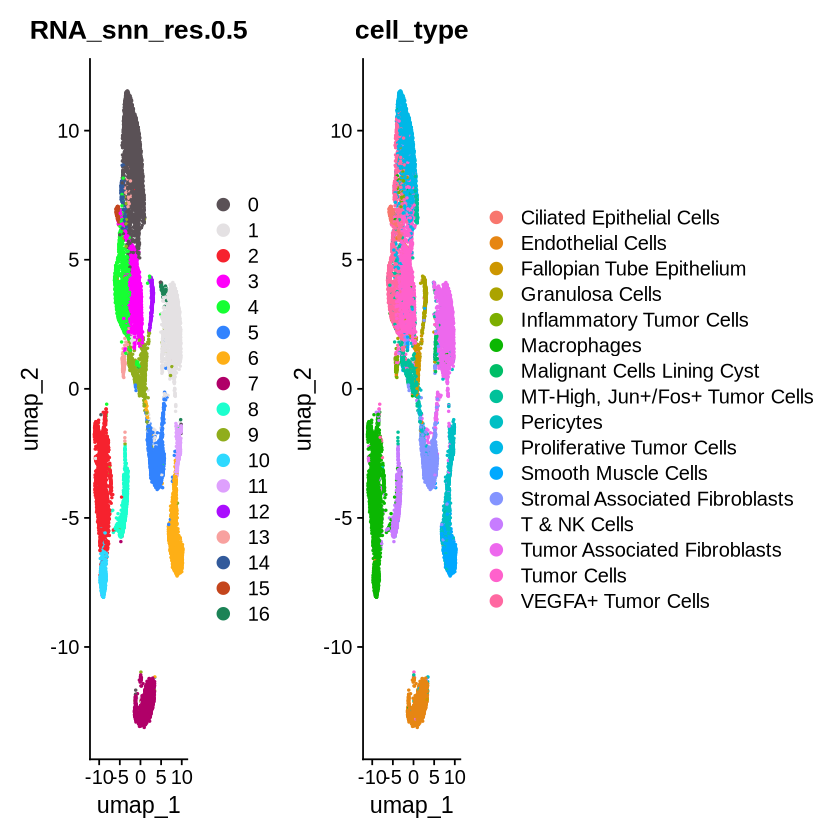

In [11]:
DefaultAssay(flex_data.obj) <- "RNA"
flex_data.obj <- NormalizeData(flex_data.obj) %>%
                 FindVariableFeatures() %>%
                 ScaleData() %>%
                 RunPCA(verbose = F) %>%
                 RunUMAP(dims = 1:15) %>%
                 FindNeighbors(dims = 1:15) %>%
                 FindClusters(resolution = 0.5)

# 可选：绘制 UMAP，按 cluster 和 cell_type 着色
p1 <- DimPlot(flex_data.obj, reduction = "umap", cols = "polychrome", 
              group.by = "RNA_snn_res.0.5", pt.size = 0.2)
p2 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "cell_type", pt.size = 0.2)
p1 + p2

In [ ]:
# ============================================
# Cell 8: 直接处理全部 Xenium 数据
# ============================================

# 检查当前细胞数量
cat("当前细胞数量:", ncol(xenium.obj), "\n")

# 使用全部数据，不创建 sketch 子集
DefaultAssay(xenium.obj) <- "Xenium"

# 标准化
xenium.obj <- NormalizeData(xenium.obj)

# 识别高变基因
xenium.obj <- FindVariableFeatures(xenium.obj)

# 直接对全部数据进行降维和聚类
xenium.obj <- ScaleData(xenium.obj) %>%
              RunPCA(npcs = 50) %>%
              RunUMAP(dims = 1:30) %>%
              FindNeighbors(reduction = "pca", dims = 1:30) %>%
              FindClusters(resolution = 0.6, cluster.name = "clusters")  # ← 关键修改：显式指定聚类结果列名

# 查看聚类结果存储在哪个列
cat("聚类结果存储在:", grep("cluster", colnames(xenium.obj@meta.data), value = TRUE), "\n")

# 可视化（使用正确的列名）
p3 <- DimPlot(xenium.obj, group.by = "clusters", label = TRUE) + 
      ggtitle("Xenium Full Data Clusters")
print(p3)

# 空间聚类图
p4 <- ImageDimPlot(xenium.obj, fov = "fov", group.by = "clusters", 
                   size = 0.5, dark.background = FALSE)
print(p4)

# 统计各聚类细胞数
cat("\n聚类细胞数统计:\n")
print(table(xenium.obj$clusters))

cat("✅ 全部数据处理完成，细胞数:", ncol(xenium.obj), "\n")

In [ ]:
# DefaultAssay(xenium.obj) <- "Xenium"
# xenium.obj <- NormalizeData(xenium.obj)
# xenium.obj <- FindVariableFeatures(xenium.obj)
# xenium.obj <- SketchData(
#     object = xenium.obj,
#     ncells = 100000,
#     method = "LeverageScore",
#     sketched.assay = "sketch"
# )

# # 切换到 sketch assay
# DefaultAssay(xenium.obj) <- "sketch"

# xenium.obj <- FindVariableFeatures(xenium.obj) %>%
#               ScaleData() %>%
#               RunPCA(npcs = 20) %>%
#               RunUMAP(dims = 1:16, return.model = TRUE) %>%
#               FindNeighbors(reduction = "pca", dims = 1:16) %>%
#               FindClusters(resolution = 0.6)

# # 可视化 sketch 数据的 UMAP 和空间聚类
# DimPlot(xenium.obj, group.by = "sketch_snn_res.0.6", cols = "polychrome", label = T)
# ImageDimPlot(xenium.obj, fov = "fov", group.by = "sketch_snn_res.0.6", 
#              cols = "polychrome", size = 0.5, dark.background = FALSE)

Normalizing layer: counts

Finding variable features for layer counts

Calcuating Leverage Score



ERROR: [1m[33mError[39m in `LeverageScore()`:[22m
[33m![39m too slow


In [ ]:
# 获取共同基因
flex_xen_common_genes <- intersect(rownames(xenium.obj), rownames(flex_data.obj))
print(length(flex_xen_common_genes))

# 将 Flex 数据子集为共同基因，并重新处理
flex_subset <- CreateSeuratObject(counts = flex_data.obj[["RNA"]]$counts[flex_xen_common_genes,],
                                  meta = flex_data.obj@meta.data) %>%
                                  NormalizeData() %>%
                                  FindVariableFeatures() %>%
                                  ScaleData() %>%
                                  RunPCA(verbose = F)

# 将 counts 矩阵读回内存（FindTransferAnchors 需要）
flex_data.obj[["RNA"]]$counts <- as(object = flex_data.obj[["RNA"]]$counts, Class = "dgCMatrix")
xenium.obj[["Xenium"]]$counts <- as(object = xenium.obj[["Xenium"]]$counts, Class = "dgCMatrix")

# 寻找锚点
anchors_from_flex <- FindTransferAnchors(
    reference = flex_subset,
    query = xenium.obj,
    query.assay = "sketch",
    features = flex_xen_common_genes,
    dims = 1:20,
    reference.reduction = "pca"
)

# 转移标签
label_transfer <- TransferData(
    anchorset = anchors_from_flex,
    refdata = flex_subset$cell_type,
    dims = 1:20
)

# 将预测结果添加到 Xenium 对象的元数据
xenium.obj <- AddMetaData(object = xenium.obj, metadata = label_transfer, col.name = 'predicted.id')

In [ ]:
# 自定义颜色（教程中给的）
custom_hex <- c("#3375AB", "#FFFF00", "#E8280E", "#8D1909", "#E47E11","#FF75A0", 
                "#19297C", "#AC674E", "#805D93", "#13B0F7", "#8980F5", "#595959", 
                "#0BFFFF", "#169873", "#8EE525", "#169873", "#52E097", "#8980F5", "#EE00B0")
names(custom_hex) <- c("Tumor Associated Fibroblasts", "Malignant Cells Lining Cyst", 
                       "Tumor Cells", "Inflammatory Tumor Cells", "Proliferative Tumor Cells", 
                       "VEGFA+ Tumor Cells", "Stromal Associated Fibroblasts", "Endothelial Cells",
                       "Stromal Associated Macrophages", "Smooth Muscle Cells", "Tumor Associated Macrophages", 
                       "T & NK Cells", "Pericytes", "Granulosa and FT Epithelial Cells", 
                       "Ciliated Epithelial Cells", "Granulosa Cells", "Fallopian Tube Epithelium", 
                       "Macrophages", "MT-High, Jun+/Fos+ Tumor Cells")

# 绘制 sketch 数据的预测标签 UMAP 和空间图
DimPlot(xenium.obj, group.by = "predicted.id", cols = custom_hex, label = T, label.size = 3)
ImageDimPlot(xenium.obj, fov = "fov", group.by = "predicted.id", cols = custom_hex, 
             size = 0.5, dark.background = FALSE)

In [ ]:
DefaultAssay(xenium.obj) <- "sketch"
xenium.obj <- ProjectData(
    object = xenium.obj,
    assay = "Xenium",
    full.reduction = "pca.full",
    sketched.assay = "sketch",
    sketched.reduction = "pca",
    umap.model = "umap",
    dims = 1:16,
    refdata = list(cluster_full = "sketch_snn_res.0.6")
)
DefaultAssay(xenium.obj) <- "Xenium"

# 将 sketch 的标签转移结果扩展到全部细胞
xenium.obj <- TransferSketchLabels(
    xenium.obj,
    sketched.assay = "sketch",
    reduction = "pca.full",
    dims = 1:16,
    refdata = list(predicted.id_full = "predicted.id"),
    k = 50,
    reduction.model = "umap",
    recompute.neighbors = FALSE,
    recompute.weights = FALSE,
    verbose = TRUE
)

# 重命名最终细胞类型列
xenium.obj@meta.data$cell_type <- xenium.obj@meta.data$predicted.id_full

# 绘制全部细胞的 UMAP 和空间图
DimPlot(xenium.obj, reduction = 'full.umap', group.by = "cell_type", 
        label = T, label.size = 3, cols = custom_hex, raster = TRUE)
ImageDimPlot(xenium.obj, fov = "fov", group.by = "cell_type", 
             cols = custom_hex, dark.background = FALSE)

In [ ]:
# 预测分数小提琴图
xenium.obj@meta.data %>%
    ggplot(aes(x = predicted.id_full, y = predicted.id_full.score, fill = predicted.id_full)) +
    geom_violin(scale = "width") +
    scale_fill_viridis(discrete = TRUE, alpha = 0.6, option = "A") +
    theme_ipsum() +
    theme(legend.position = "none",
          axis.text.x = element_text(angle = 45, hjust = 1)) +
    ggtitle("Label Transfer Prediction Scores") +
    xlab("") + ylab("label prediction score") + ylim(0, 1)

# 预测分数 UMAP 图
FeaturePlot(xenium.obj, reduction = 'full.umap', features = "predicted.id_full.score", raster = TRUE)

In [ ]:
cell_groups <- xenium.obj@meta.data %>%
    rownames_to_column(var = "cell_id") %>%
    select(cell_id, group = cell_type)

write.csv(cell_groups, "cell_groups.csv", row.names = FALSE)